# CNMC Dataset Preparation for FLEX-Med v2.0 (Runtime Dirichlet Partitioning)

This notebook prepares the **complete CNMC dataset** for federated learning with **runtime Dirichlet partitioning**.

## Key Changes in v2.0:
- **3-folder structure**: `cnmc_public_anchor` (from train), `cnmc_public_test` (from validation), `cnmc_local_train` (from train)
- **No pre-split clients**: Remaining **training** split (after the balanced anchor draw) goes into `cnmc_local_train` (partitioned at runtime)
- **Dirichlet partitioning**: Heterogeneity controlled via `DIRICHLET_ALPHA` parameter in FL system

**Output Location:**
- `/content/drive/MyDrive/College/FLEX-Med/datasets/cnmc/`

**Data Sources:**
- `training_data/fold_0/`, `fold_1/`, `fold_2/`: Labeled via folder structure (all/hem) ✓
- `validation_data/C-NMC_test_prelim_phase_data/`: Labeled via CSV file ✓
- `testing_data/C-NMC_test_final_phase_data/`: **Unlabeled** (excluded) ✗

**Folder Structure:**
```
/content/drive/MyDrive/College/Datasets/CNMC/
├── training_data/
│   ├── fold_0/
│   │   ├── all/  (ALL/Leukemia images)
│   │   └── hem/  (Healthy images)
│   ├── fold_1/
│   │   ├── all/
│   │   └── hem/
│   └── fold_2/
│       ├── all/
│       └── hem/
├── validation_data/
│   ├── C-NMC_test_prelim_phase_data/  (images)
│   └── C-NMC_test_prelim_phase_data_labels.csv  (labels)
└── testing_data/
    └── C-NMC_test_final_phase_data/  (unlabeled - excluded)
```

**Output Datasets:**
1. **cnmc_public_anchor**: Subsampled from the original training split, used as the shared dataset for consensus distillation - **balanced 50/50**
2. **cnmc_public_test**: The original CNMC validation split repurposed as the final held-out test set
3. **cnmc_local_train**: The remainder of the original training split used for FL clients - **class imbalanced** (~68% ALL, 32% Healthy)

**Strategy:**
- The original CNMC validation split was retained as the final held-out test set. Only the original training split was used to construct the public anchor set and local federated training pool. This avoids mixing training and validation sources during model development and yields a cleaner experimental design.
- Stratified split for balanced public anchor set
- **Runtime partitioning** via Flower's DirichletPartitioner (in task.py)
- **Class imbalance**: ~weighted random sampling in FL code

In [ ]:
# Mount Google Drive (Colab only)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import required libraries
import os
import shutil
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Set random seed for reproducibility
np.random.seed(42)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## Configuration

In [ ]:
# Base paths
BASE_PATH = "/content/drive/MyDrive/College"
DATASET_PATH = os.path.join(BASE_PATH, "Datasets/CNMC")
OUTPUT_PATH = os.path.join(BASE_PATH, "FLEX-Med/datasets/cnmc")

# Input paths
TRAINING_DATA_PATH = os.path.join(DATASET_PATH, "training_data")
VALIDATION_DATA_PATH = os.path.join(DATASET_PATH, "validation_data/C-NMC_test_prelim_phase_data")
VALIDATION_LABELS_CSV = os.path.join(DATASET_PATH, "validation_data/C-NMC_test_prelim_phase_data_labels.csv")

# Output paths (v2.0 - 3 folders only)
PUBLIC_ANCHOR_PATH = os.path.join(OUTPUT_PATH, "cnmc_public_anchor")
PUBLIC_TEST_PATH = os.path.join(OUTPUT_PATH, "cnmc_public_test")
LOCAL_TRAIN_PATH = os.path.join(OUTPUT_PATH, "cnmc_local_train")  # NEW: Combined training data

PUBLIC_ANCHOR_RATIO = 0.20

print(f"Configuration (v2.0 - Runtime Dirichlet Partitioning):")
print(f"{'='*70}")
print(f"  Base Path: {BASE_PATH}")
print(f"  Dataset Path: {DATASET_PATH}")
print(f"  Output Path: {OUTPUT_PATH}")
print(f"\nInput Paths:")
print(f"  Training: {TRAINING_DATA_PATH} (fold_0, fold_1, fold_2)")
print(f"  Validation: {VALIDATION_DATA_PATH}")
print(f"  Validation CSV: {VALIDATION_LABELS_CSV}")
print(f"\nData Split (NEW):")
print(f"  Public Anchor: {PUBLIC_ANCHOR_RATIO*100:.0f}% (balanced, for distillation)")
print(f"  Public Test: original CNMC validation split, used as final held-out test set")
print(f"  Local Train: remainder of original training after anchor (→ {LOCAL_TRAIN_PATH})")
print(f"\n✨ Key Change:")
print(f"  - No pre-split client folders")
print(f"  - Remaining training split → cnmc_local_train/ (after anchor)")
print(f"  - Partitioning via DirichletPartitioner in task.py")
print(f"  - Control heterogeneity with DIRICHLET_ALPHA parameter")
print(f"{'='*70}")

Configuration (v2.0 - Runtime Dirichlet Partitioning):
  Base Path: /content/drive/MyDrive/College
  Dataset Path: /content/drive/MyDrive/College/Datasets/CNMC
  Output Path: /content/drive/MyDrive/College/FLEX-Med/backend/datasets/cnmc

Input Paths:
  Training: /content/drive/MyDrive/College/Datasets/CNMC/training_data (fold_0, fold_1, fold_2)
  Validation: /content/drive/MyDrive/College/Datasets/CNMC/validation_data/C-NMC_test_prelim_phase_data
  Validation CSV: /content/drive/MyDrive/College/Datasets/CNMC/validation_data/C-NMC_test_prelim_phase_data_labels.csv

Data Split (NEW):
  Public Anchor: 20% (balanced, for distillation)
  Public Test: original CNMC validation split, used as final held-out test set
  Local Train: remainder of original training after anchor (saved to cnmc_local_train)

✨ Key Change:
  - No pre-split client folders
  - Remaining training split → cnmc_local_train/ (after anchor)
  - Partitioning via DirichletPartitioner in task.py
  - Control heterogeneity with 

## Step 1: Load Training Data (Labeled via Folder Structure)

In [ ]:
def load_training_data(training_path):
    """
    Load training data from fold structure (fold_0, fold_1, fold_2).
    Each fold contains: all/ and hem/ subdirectories.
    Returns: list of tuples (image_path, label)
    """
    data = []

    # Class mapping: 0 = ALL (Leukemia), 1 = Healthy
    # Note: ImageFolder loads alphabetically, so 'all' = 0, 'hem' = 1
    class_folders = {
        'all': 0,  # ALL/Leukemia
        'hem': 1   # Healthy
    }

    # Find all fold directories (fold_0, fold_1, fold_2, etc.)
    fold_dirs = []
    if os.path.exists(training_path):
        fold_dirs = sorted([d for d in os.listdir(training_path)
                           if os.path.isdir(os.path.join(training_path, d)) and d.startswith('fold_')])

    if not fold_dirs:
        print(f"⚠️  Warning: No fold directories found in {training_path}")
        return data

    print(f"Found {len(fold_dirs)} folds: {fold_dirs}")
    print("")

    # Load data from each fold
    for fold_name in fold_dirs:
        fold_path = os.path.join(training_path, fold_name)
        print(f"Loading {fold_name}:")

        for class_name, label in class_folders.items():
            class_path = os.path.join(fold_path, class_name)

            if not os.path.exists(class_path):
                print(f"  ⚠️  Warning: {class_path} not found")
                continue

            # Get all image files
            image_files = [f for f in os.listdir(class_path)
                          if f.lower().endswith(('.bmp', '.jpg', '.jpeg', '.png'))]

            for img_file in image_files:
                img_path = os.path.join(class_path, img_file)
                data.append((img_path, label))

            print(f"  {class_name}: {len(image_files)} images (label={label})")

        print("")

    return data

print("="*70)
print("Loading training data from all folds...")
print("="*70)
training_data = load_training_data(TRAINING_DATA_PATH)
print(f"✓ Total training samples (all folds): {len(training_data)}")
print("="*70)

Loading training data from all folds...
Found 3 folds: ['fold_0', 'fold_1', 'fold_2']

Loading fold_0:
  all: 2397 images (label=0)
  hem: 1130 images (label=1)

Loading fold_1:
  all: 2418 images (label=0)
  hem: 1163 images (label=1)

Loading fold_2:
  all: 2458 images (label=0)
  hem: 1096 images (label=1)

✓ Total training samples (all folds): 10662


## Step 2: Load Validation Data (Labeled via CSV)

In [ ]:
def load_validation_data(validation_path, csv_path):
    """
    Load validation data using CSV labels.
    CSV format: Patient_ID, new_names, labels
    Returns: list of tuples (image_path, label)
    """
    data = []

    # Read CSV
    if not os.path.exists(csv_path):
        print(f"⚠️  Warning: CSV not found at {csv_path}")
        return data

    df = pd.read_csv(csv_path)
    print(f"\nCSV Preview:")
    print(df.head())
    print(f"\nCSV Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")

    # Clean column names (remove extra spaces)
    df.columns = df.columns.str.strip()

    # Map labels to match training data convention
    label_counts = Counter()

    for _, row in df.iterrows():
        # Get image filename from CSV
        if 'new_names' in df.columns:
            img_filename = row['new_names']
        elif 'Patient_ID' in df.columns:
            img_filename = row['Patient_ID']
        else:
            print(f"⚠️  Error: Cannot find image filename column in CSV")
            continue

        img_path = os.path.join(validation_path, img_filename)

        # Check if image exists
        if not os.path.exists(img_path):
            # Try with .bmp extension if not found
            if not img_filename.lower().endswith('.bmp'):
                img_path = os.path.join(validation_path, img_filename + '.bmp')

            if not os.path.exists(img_path):
                continue

        # Get label from CSV (1 = ALL, 0 = Healthy)
        label = int(row['labels'])

        # Invert label to match our convention (0 = ALL, 1 = Healthy)
        label = 1 - label

        data.append((img_path, label))
        label_counts[label] += 1

    print(f"\nLoaded validation data:")
    print(f"  ALL (Leukemia, label=0): {label_counts[0]} images")
    print(f"  Healthy (label=1): {label_counts[1]} images")

    return data

print("\n" + "="*70)
print("Loading validation data from CSV...")
print("="*70)
validation_data = load_validation_data(VALIDATION_DATA_PATH, VALIDATION_LABELS_CSV)
print(f"\n✓ Total validation samples: {len(validation_data)}")
print("="*70)


Loading validation data from CSV...

CSV Preview:
             Patient_ID new_names  labels
0   UID_57_29_1_all.bmp     1.bmp       1
1   UID_57_22_2_all.bmp     2.bmp       1
2   UID_57_31_3_all.bmp     3.bmp       1
3  UID_H49_35_1_hem.bmp     4.bmp       0
4   UID_58_6_13_all.bmp     5.bmp       1

CSV Shape: (1867, 3)
Columns: ['Patient_ID', 'new_names', 'labels']

Loaded validation data:
  ALL (Leukemia, label=0): 1219 images
  Healthy (label=1): 648 images

✓ Total validation samples: 1867


## Step 3: Data Processing

In [ ]:
# all_data = training_data + validation_data

# Convert to numpy arrays for easier manipulation
train_image_paths = np.array([item[0] for item in training_data])
train_labels = np.array([item[1] for item in training_data])

val_image_paths = np.array([item[0] for item in validation_data])
val_labels = np.array([item[1] for item in validation_data])

# Count class distribution
train_label_counts = Counter(train_labels)
val_label_counts = Counter(val_labels)

print(f"\n{'='*70}")
print(f"Dataset Statistics:")
print(f"{'='*70}")
print(f"Training data (all folds): {len(training_data)} samples")
print(f"Validation data:           {len(validation_data)} samples")
print(f"{'='*70}")



Dataset Statistics:
Training data (all folds): 10662 samples
Validation data:           1867 samples


## Step 4: Build Public Anchor, Public Test, and Local Train

**Key Strategy:**
- **Public Anchor**: Balanced 50/50 sample from **training only**; target size driven by `PUBLIC_ANCHOR_RATIO` × (train+val) total
- **Public Test**: **Entire** official CNMC validation split (no further split)
- **Local Train**: **Remaining training** after anchor (class-imbalanced; exact ALL/Healthy mix is data-dependent) — partitioned at runtime

In [ ]:
print("\nCreating Datasets: Original Validation Split -> Public Test, Original Training Split -> Public Anchor & Local Train...")

# 1. Public Test is exactly the validation set
# The user instruction: "Load validation_data and assign it entirely to cnmc_public_test."
X_public_test = val_image_paths
y_public_test = val_labels

# 2. From training only: balanced anchor (target ~PUBLIC_ANCHOR_RATIO of full corpus) + local train = remainder
total_samples = len(training_data) + len(validation_data)
n_public_anchor_target = int(total_samples * PUBLIC_ANCHOR_RATIO) # public anchor is 20% of the total samples
n_anchor_per_class = n_public_anchor_target // 2

# Separate training indices by class
indices_all = np.where(train_labels == 0)[0]
indices_hem = np.where(train_labels == 1)[0]

# Shuffle indices (random_state=42 for reproducibility)
np.random.seed(42)
np.random.shuffle(indices_all)
np.random.shuffle(indices_hem)

# Select indices for Public Anchor (balanced)
anchor_indices = np.concatenate([
    indices_all[:n_anchor_per_class],
    indices_hem[:n_anchor_per_class]
])

# Select remaining indices for Local Train (whatever is left - class imbalanced)
local_train_indices = np.concatenate([
    indices_all[n_anchor_per_class:],
    indices_hem[n_anchor_per_class:]
])

# Create the splits from training data
X_public_anchor = train_image_paths[anchor_indices]
y_public_anchor = train_labels[anchor_indices]

X_local_train = train_image_paths[local_train_indices]
y_local_train = train_labels[local_train_indices]

# Shuffle the splits internally
p_test = np.random.permutation(len(X_public_test))
X_public_test = X_public_test[p_test]
y_public_test = y_public_test[p_test]

p_anchor = np.random.permutation(len(X_public_anchor))
X_public_anchor = X_public_anchor[p_anchor]
y_public_anchor = y_public_anchor[p_anchor]

p_train = np.random.permutation(len(X_local_train))
X_local_train = X_local_train[p_train]
y_local_train = y_local_train[p_train]

print(f"\n{'='*70}")
print(f"Data Split Summary (v2.0 - 3 Folders):")
print(f"{'='*70}")
print(f"Total samples: {total_samples}")

print(f"\nPublic Anchor (for distillation):")
print(f"  Total: {len(X_public_anchor)} ({len(X_public_anchor)/total_samples*100:.1f}%)")
print(f"  ALL: {sum(y_public_anchor == 0)}, Healthy: {sum(y_public_anchor == 1)}")
if max(sum(y_public_anchor == 0), sum(y_public_anchor == 1)) > 0:
    print(f"  Balance ratio: {min(sum(y_public_anchor == 0), sum(y_public_anchor == 1)) / max(sum(y_public_anchor == 0), sum(y_public_anchor == 1)):.2f} ✓")

print(f"\nPublic Test (for evaluation - from validation set):")
print(f"  Total: {len(X_public_test)} ({len(X_public_test)/total_samples*100:.1f}%)")
print(f"  ALL: {sum(y_public_test == 0)}, Healthy: {sum(y_public_test == 1)}")
if max(sum(y_public_test == 0), sum(y_public_test == 1)) > 0:
    print(f"  Balance ratio: {min(sum(y_public_test == 0), sum(y_public_test == 1)) / max(sum(y_public_test == 0), sum(y_public_test == 1)):.2f}")

print(f"\nLocal Train (for runtime partitioning):")
print(f"  Total: {len(X_local_train)} ({len(X_local_train)/total_samples*100:.1f}%)")
print(f"  ALL: {sum(y_local_train == 0)} ({sum(y_local_train == 0)/len(y_local_train)*100:.1f}%)")
print(f"  Healthy: {sum(y_local_train == 1)} ({sum(y_local_train == 1)/len(y_local_train)*100:.1f}%)")
if max(sum(y_local_train == 0), sum(y_local_train == 1)) > 0:
    print(f"  Balance ratio: {min(sum(y_local_train == 0), sum(y_local_train == 1)) / max(sum(y_local_train == 0), sum(y_local_train == 1)):.2f}")
print(f"  → Will be partitioned at runtime via DirichletPartitioner")
print(f"{'='*70}")



Creating splits: Validation -> Public Test, Training -> Public Anchor & Local Train...

Data Split Summary (v2.0 - 3 Folders):
Total samples: 12529

Public Anchor (for distillation):
  Total: 2504 (20.0%)
  ALL: 1252, Healthy: 1252
  Balance ratio: 1.00 ✓

Public Test (for evaluation - from validation set):
  Total: 1867 (14.9%)
  ALL: 1219, Healthy: 648
  Balance ratio: 0.53

Local Train (for runtime partitioning):
  Total: 8158 (65.1%)
  ALL: 6021 (73.8%)
  Healthy: 2137 (26.2%)
  Balance ratio: 0.35
  → Will be partitioned at runtime via DirichletPartitioner


## Step 5: Create Output Directory Structure

In [ ]:
def create_dataset_structure(X, y, output_path, description):
    """
    Create ImageFolder structure: output_path/all and output_path/hem
    """
    print(f"\nCreating {description}...")

    # Create directories
    all_dir = os.path.join(output_path, 'all')  # ALL/Leukemia (label=0)
    hem_dir = os.path.join(output_path, 'hem')  # Healthy (label=1)

    os.makedirs(all_dir, exist_ok=True)
    os.makedirs(hem_dir, exist_ok=True)

    # Copy images to appropriate folders
    all_count = 0
    hem_count = 0

    for img_path, label in zip(X, y):
        # Determine destination folder
        if label == 0:  # ALL
            dest_dir = all_dir
            all_count += 1
        else:  # Healthy
            dest_dir = hem_dir
            hem_count += 1

        # Create unique filename
        img_filename = os.path.basename(img_path)
        dest_path = os.path.join(dest_dir, img_filename)

        # Handle duplicate filenames
        counter = 1
        while os.path.exists(dest_path):
            name, ext = os.path.splitext(img_filename)
            dest_path = os.path.join(dest_dir, f"{name}_{counter}{ext}")
            counter += 1

        # Copy image
        try:
            shutil.copy2(img_path, dest_path)
        except Exception as e:
            print(f"  ⚠️  Error copying {img_path}: {e}")

    print(f"  ✓ Created: {output_path}")
    print(f"    ALL: {all_count} images")
    print(f"    Healthy: {hem_count} images")

    return all_count, hem_count

# Clean output directory if it exists
if os.path.exists(OUTPUT_PATH):
    print(f"\n⚠️  Warning: Output directory exists: {OUTPUT_PATH}")
    print("Cleaning existing datasets...")
    shutil.rmtree(OUTPUT_PATH)

os.makedirs(OUTPUT_PATH, exist_ok=True)

print(f"\n{'='*70}")
print(f"Creating Output Datasets (v2.0 - 3 Folders):")
print(f"{'='*70}")


⚠️  Warning: Output directory exists: /content/drive/MyDrive/College/FLEX-Med/backend/datasets/cnmc
Cleaning existing datasets...

Creating Output Datasets (v2.0 - 3 Folders):


In [ ]:
# Create public anchor dataset (balanced 50/50 from train; count set by PUBLIC_ANCHOR_RATIO)
anchor_all, anchor_hem = create_dataset_structure(
    X_public_anchor, y_public_anchor,
    PUBLIC_ANCHOR_PATH,
    "Public Anchor Dataset (balanced subsample from training for consensus distillation)"
)


Creating Public Anchor Dataset (20%, balanced for consensus distillation)...
  ✓ Created: /content/drive/MyDrive/College/FLEX-Med/backend/datasets/cnmc/cnmc_public_anchor
    ALL: 1252 images
    Healthy: 1252 images


In [ ]:
# Create public test dataset from the provided CNMC validation split
test_all, test_hem = create_dataset_structure(
    X_public_test, y_public_test,
    PUBLIC_TEST_PATH,
    "Public Test Dataset (original validation split)"
)


Creating Public Test Dataset (original validation split)...
  ✓ Created: /content/drive/MyDrive/College/FLEX-Med/backend/datasets/cnmc/cnmc_public_test
    ALL: 1219 images
    Healthy: 648 images


In [ ]:
# Create local train dataset (remaining training; class imbalanced — runtime Dirichlet partitioning)
train_all, train_hem = create_dataset_structure(
    X_local_train, y_local_train,
    LOCAL_TRAIN_PATH,
    "Local Train Dataset (remaining training split; runtime partitioning)"
)


Creating Local Train Dataset (remaining training split; runtime partitioning)...
  ✓ Created: /content/drive/MyDrive/College/FLEX-Med/backend/datasets/cnmc/cnmc_local_train
    ALL: 6021 images
    Healthy: 2137 images


## Step 6: Create Summary Report

In [ ]:
# Generate summary report
summary_report = {
    'version': '2.0',
    'partitioning_method': 'runtime_dirichlet',
    'total_samples': total_samples,
    'public_anchor': {
        'total': len(X_public_anchor),
        'all': anchor_all,
        'healthy': anchor_hem,
        'percentage': len(X_public_anchor) / total_samples * 100,
        'balance_ratio': min(anchor_all, anchor_hem) / max(anchor_all, anchor_hem),
        'purpose': 'Consensus distillation (balanced 50/50)'
    },
    'public_test': {
        'total': len(X_public_test),
        'all': test_all,
        'healthy': test_hem,
        'percentage': len(X_public_test) / total_samples * 100,
        'balance_ratio': min(test_all, test_hem) / max(test_all, test_hem),
        'purpose': 'Unbiased evaluation (balanced 50/50)'
    },
    'local_train': {
        'total': len(X_local_train),
        'all': train_all,
        'healthy': train_hem,
        'percentage': len(X_local_train) / total_samples * 100,
        'all_percentage': train_all / len(X_local_train) * 100,
        'healthy_percentage': train_hem / len(X_local_train) * 100,
        'balance_ratio': min(train_all, train_hem) / max(train_all, train_hem),
        'purpose': 'Combined training data for all clients (partitioned at runtime)',
        'note': 'Class imbalanced - weighted random sampling'
    },
    'fl_config': {
        'dirichlet_alpha': 'configured in backend/.env (FLEX_MED_DIRICHLET_ALPHA)',
        'dirichlet_seed': 42,
        'num_clients': 'dynamic (set at runtime)',
        'partitioner': 'flwr_datasets.partitioner.DirichletPartitioner'
    }
}

# Save summary as JSON
summary_path = os.path.join(OUTPUT_PATH, 'dataset_summary.json')
with open(summary_path, 'w') as f:
    json.dump(summary_report, f, indent=2)

print(f"\n{'='*70}")
print(f"Final Summary (v2.0):")
print(f"{'='*70}")
print(json.dumps(summary_report, indent=2))



Final Summary (v2.0):
{
  "version": "2.0",
  "partitioning_method": "runtime_dirichlet",
  "total_samples": 12529,
  "public_anchor": {
    "total": 2504,
    "all": 1252,
    "healthy": 1252,
    "percentage": 19.98563333067284,
    "balance_ratio": 1.0,
    "purpose": "Consensus distillation (balanced 50/50)"
  },
  "public_test": {
    "total": 1867,
    "all": 1219,
    "healthy": 648,
    "percentage": 14.901428685449755,
    "balance_ratio": 0.5315832649712879,
    "purpose": "Unbiased evaluation (balanced 50/50)"
  },
  "local_train": {
    "total": 8158,
    "all": 6021,
    "healthy": 2137,
    "percentage": 65.1129379838774,
    "all_percentage": 73.80485413091445,
    "healthy_percentage": 26.19514586908556,
    "balance_ratio": 0.354924431157615,
    "purpose": "Combined training data for all clients (partitioned at runtime)",
    "note": "Class imbalanced - weighted random sampling"
  },
  "fl_config": {
    "dirichlet_alpha": "configured in backend/.env (FLEX_MED_DIRICH

## Step 7: Visualize Final Distribution

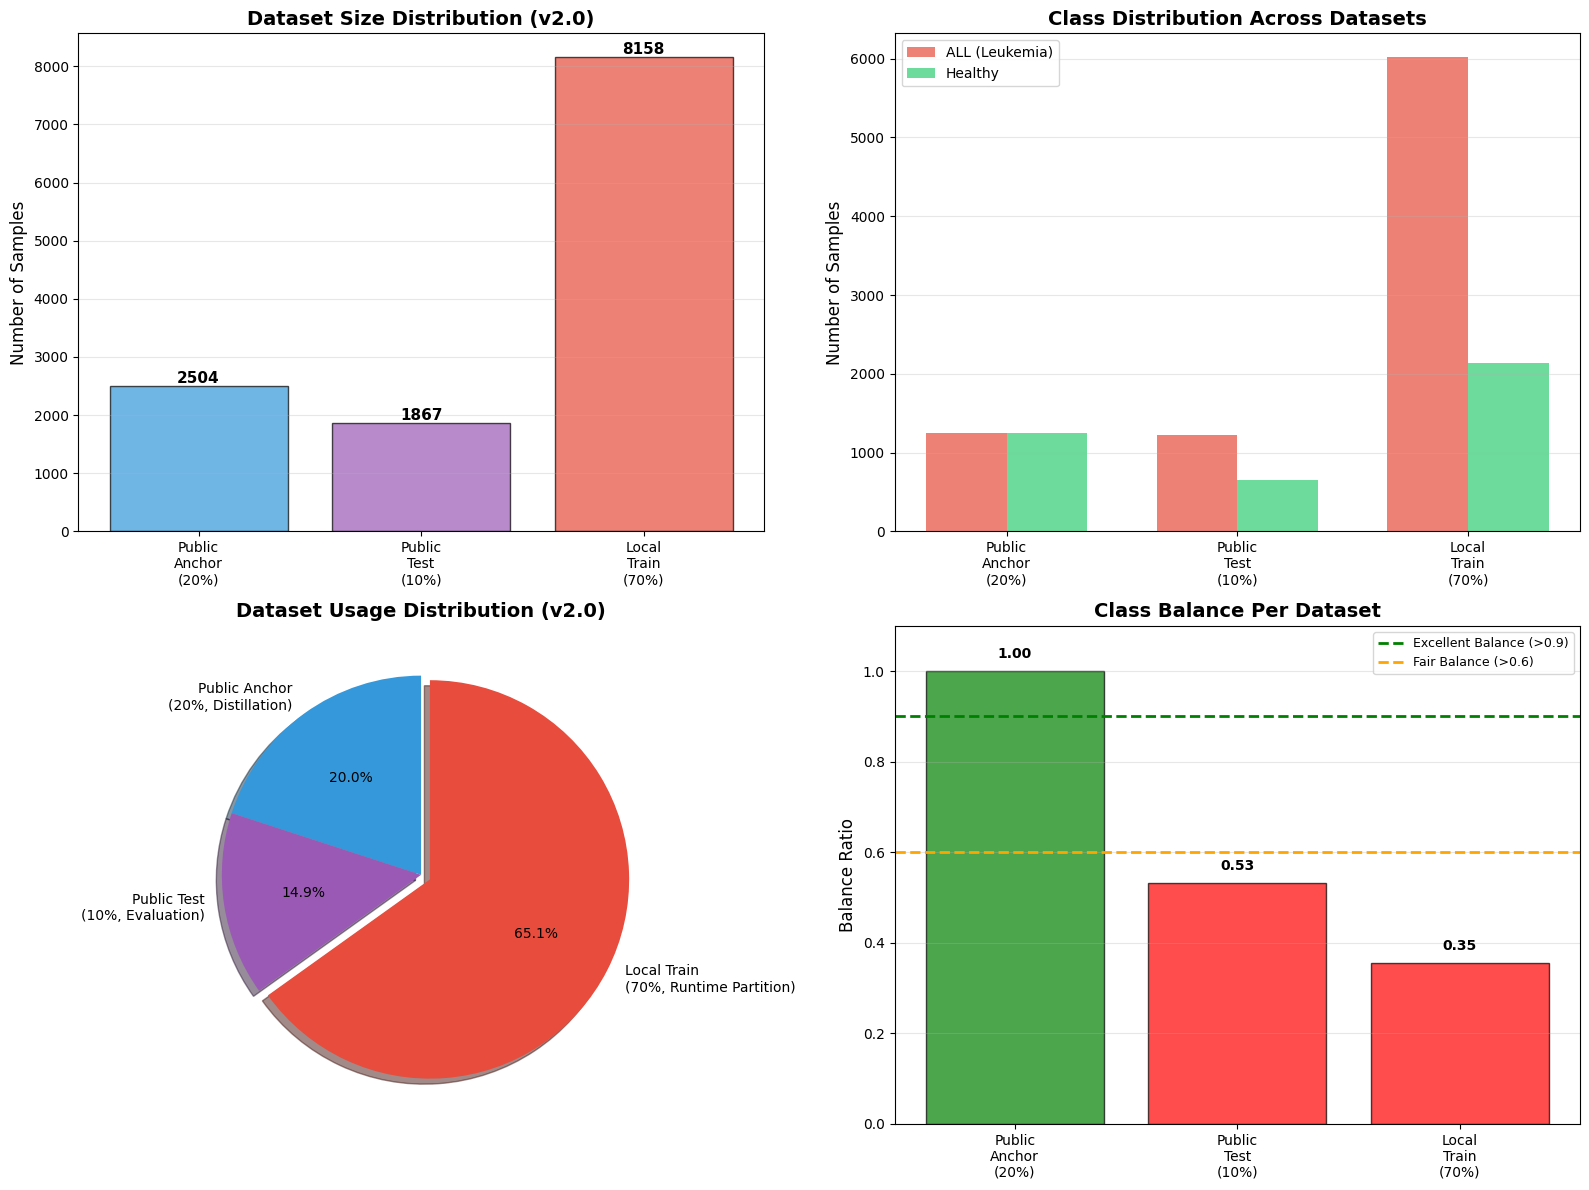


✓ Visualization saved to: /content/drive/MyDrive/College/FLEX-Med/backend/datasets/cnmc/dataset_distribution.png


In [ ]:
# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Overall distribution
datasets = ['Public\nAnchor\n(balanced)', 'Public\nTest\n(full val)', 'Local\nTrain\n(rest of train)']
totals = [len(X_public_anchor), len(X_public_test), len(X_local_train)]
colors_bar = ['#3498db', '#9b59b6', '#e74c3c']

axes[0, 0].bar(datasets, totals, color=colors_bar, alpha=0.7, edgecolor='black')
axes[0, 0].set_ylabel('Number of Samples', fontsize=12)
axes[0, 0].set_title('Dataset Size Distribution (v2.0)', fontsize=14, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)
for i, (ds, total) in enumerate(zip(datasets, totals)):
    axes[0, 0].text(i, total + 50, str(total), ha='center', fontsize=11, fontweight='bold')

# Plot 2: Class distribution across datasets
x = np.arange(len(datasets))
width = 0.35

all_counts = [anchor_all, test_all, train_all]
hem_counts = [anchor_hem, test_hem, train_hem]

axes[0, 1].bar(x - width/2, all_counts, width, label='ALL (Leukemia)', color='#e74c3c', alpha=0.7)
axes[0, 1].bar(x + width/2, hem_counts, width, label='Healthy', color='#2ecc71', alpha=0.7)
axes[0, 1].set_ylabel('Number of Samples', fontsize=12)
axes[0, 1].set_title('Class Distribution Across Datasets', fontsize=14, fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(datasets)
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# Plot 3: Percentage distribution pie chart
sizes = [len(X_public_anchor), len(X_public_test), len(X_local_train)]
labels_pie = ['Public Anchor\n(balanced, distillation)', 'Public Test\n(full validation)',
              'Local Train\n(remainder of train)']
colors_pie = ['#3498db', '#9b59b6', '#e74c3c']
explode = (0, 0, 0.05)  # Emphasize local train

axes[1, 0].pie(sizes, labels=labels_pie, autopct='%1.1f%%', colors=colors_pie,
               startangle=90, textprops={'fontsize': 10}, explode=explode, shadow=True)
axes[1, 0].set_title('Dataset Usage Distribution (v2.0)', fontsize=14, fontweight='bold')

# Plot 4: Balance ratio per dataset
balance_ratios = []
for all_c, hem_c in zip(all_counts, hem_counts):
    ratio = min(all_c, hem_c) / max(all_c, hem_c) if max(all_c, hem_c) > 0 else 0
    balance_ratios.append(ratio)

colors_balance = ['green' if r > 0.9 else 'orange' if r > 0.6 else 'red' for r in balance_ratios]
axes[1, 1].bar(datasets, balance_ratios, color=colors_balance, alpha=0.7, edgecolor='black')
axes[1, 1].axhline(y=0.9, color='green', linestyle='--', linewidth=2, label='Excellent Balance (>0.9)')
axes[1, 1].axhline(y=0.6, color='orange', linestyle='--', linewidth=2, label='Fair Balance (>0.6)')
axes[1, 1].set_ylabel('Balance Ratio', fontsize=12)
axes[1, 1].set_title('Class Balance Per Dataset', fontsize=14, fontweight='bold')
axes[1, 1].set_ylim(0, 1.1)
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(axis='y', alpha=0.3)

# Add annotations
for i, (ds, ratio) in enumerate(zip(datasets, balance_ratios)):
    axes[1, 1].text(i, ratio + 0.03, f"{ratio:.2f}", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
viz_path = os.path.join(OUTPUT_PATH, 'dataset_distribution.png')
plt.savefig(viz_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Visualization saved to: {viz_path}")

## Step 8: Completion Summary & Next Steps

In [ ]:
print(f"\n{'='*70}")
print(f"✓ CNMC Dataset Preparation Complete (v2.0)!")
print(f"{'='*70}")
print(f"\nOutput directory: {OUTPUT_PATH}")
print(f"\nCreated datasets:")
print(f"  1. cnmc_public_anchor/    - {len(X_public_anchor)} samples (20%, balanced)")
print(f"  2. cnmc_public_test/      - {len(X_public_test)} samples (Validation Split)")
print(f"  3. cnmc_local_train/      - {len(X_local_train)} samples (remainder of training; class imbalanced)")

print(f"\n{'='*70}")
print(f"How Runtime Dirichlet Partitioning Works:")
print(f"{'='*70}")
print(f"\n1. FL Initialization:")
print(f"   - task.py loads cnmc_local_train/ (all {len(X_local_train)} samples)")
print(f"   - DirichletPartitioner creates heterogeneous partitions")
   - Each client gets a subset based on partition_id")
\n2. Heterogeneity Control:")
print(f"   - Set via FLEX_MED_DIRICHLET_ALPHA in backend/.env")
print(f"   - alpha=0.1: Extreme heterogeneity (very skewed)")
print(f"   - alpha=0.5: Moderate heterogeneity (recommended)")
print(f"   - alpha=1.0: Mild heterogeneity")
print(f"   - alpha=10.0: Nearly IID")

print(f"\n3. No Re-preparation Needed:")
print(f"   - Change num_clients: just update flwr config")
print(f"   - Change alpha: just update .env file")
print(f"   - Same dataset works for 2, 3, 5, 10+ clients")

print(f"\n{'='*70}")
print(f"Environment Configuration:")
print(f"{'='*70}")
print(f"\nAdd to backend/.env or backend/federated_learning/.env:")
print(f"")
print(f"# Dataset paths (defaults shown)")
print(f"PUBLIC_ANCHOR_DATASET_PATH={PUBLIC_ANCHOR_PATH}")
print(f"PUBLIC_TEST_DATASET_PATH={PUBLIC_TEST_PATH}")
print(f"LOCAL_TRAIN_DATASET_PATH={LOCAL_TRAIN_PATH}")
print(f"")
print(f"# Dirichlet partitioning (defaults shown)")
print(f"FLEX_MED_DIRICHLET_ALPHA=0.5  # Moderate heterogeneity")
print(f"FLEX_MED_DIRICHLET_SEED=42")
print(f"FLEX_MED_DIRICHLET_MIN_PARTITION_SIZE=100")

print(f"\n{'='*70}")
print(f"Client Configuration (client_data.json):")
print(f"{'='*70}")
print(f"\nNOTE: dataset_path is NO LONGER NEEDED (deprecated in v2.0)")
print(f"\nExample client_data.json:")
print(f"[")
print(f"  {{")
print(f"    \"id\": 0,")
print(f"    \"client_name\": \"Hospital_A\",")
print(f"    \"model_type\": \"resnet18\",")
print(f"    \"has_local_data\": true,")
print(f"    \"model_path\": \"/path/to/models/client_0.pt\",")
print(f"    \"metrics\": \"{{}}\"")
print(f"  }},")
print(f"  {{")
print(f"    \"id\": 1,")
print(f"    \"client_name\": \"Hospital_B\",")
print(f"    \"model_type\": \"mobilenet_v2\",")
print(f"    \"has_local_data\": true,")
print(f"    \"model_path\": \"/path/to/models/client_1.pt\",")
print(f"    \"metrics\": \"{{}}\"")
print(f"  }}")
print(f"]")

print(f"\n{'='*70}")
print(f"Run FL Simulation:")
print(f"{'='*70}")
print(f"\ncd backend/federated_learning")
print(f"flwr run . --run-config num-supernodes=2")
print(f"")
print(f"# Test different configurations")
print(f"FLEX_MED_DIRICHLET_ALPHA=0.1 flwr run . --run-config num-supernodes=3")
print(f"FLEX_MED_DIRICHLET_ALPHA=1.0 flwr run . --run-config num-supernodes=5")

print(f"\n{'='*70}")
print(f"Expected Log Output:")
print(f"{'='*70}")
print(f"[Partitioner] Loaded {len(X_local_train)} samples from {LOCAL_TRAIN_PATH}")
print(f"[Partitioner] Class distribution: ALL={train_all}, Healthy={train_hem}")
print(f"[Partitioner] Created Dirichlet partitioner:")
print(f"  - Num partitions: 2")
print(f"  - Alpha: 0.5")
print(f"  - Seed: 42")
print(f"[Data] Client 0 partition:")
print(f"  - Total samples: XXXX")
print(f"  - ALL: XXXX (XX.X%)")
print(f"  - Healthy: XXXX (XX.X%)")

print(f"\n{'='*70}")
print(f"Dataset Summary:")
print(f"{'='*70}")
print(f"Total CNMC samples: {total_samples}")
print(f"  Class distribution: ~{label_counts[0]/label_counts[1]:.1f}:1 (ALL:Healthy)")
print(f"\nPublic Anchor: {len(X_public_anchor)} ({len(X_public_anchor)/total_samples*100:.1f}% of train+val, balanced)")
print(f"Public Test: {len(X_public_test)} ({len(X_public_test)/total_samples*100:.1f}% of train+val; full official validation)")
print(f"Local Train: {len(X_local_train)} ({len(X_local_train)/total_samples*100:.1f}% of train+val; remainder of training)")
print(f"  → Partitioned at runtime using DirichletPartitioner")
print(f"  → Heterogeneity controlled by DIRICHLET_ALPHA")
print(f"\n✨ Benefits:")
print(f"  ✓ No pre-split client folders needed")
print(f"  ✓ Change num_clients without re-preparation")
print(f"  ✓ Experiment with different alpha values instantly")
print(f"  ✓ Reproducible with seed control")


IndentationError: unexpected indent (2127959605.py, line 16)